# Autoencoder Training Notebook (Residual Backbone Variant)

This notebook runs the residual autoencoder experiment on the shared `64x64` 5% test-defect dataset and uses the same evaluation flow as the baseline notebook.


In [7]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
import torch
from torch.utils.data import DataLoader

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.config import load_toml
from wafer_defect.data.wm811k import WaferMapDataset
from wafer_defect.models.autoencoder import build_autoencoder_from_config
from wafer_defect.scoring import absolute_error_map, squared_error_map, spatial_mean, topk_spatial_mean
from wafer_defect.training.autoencoder import run_autoencoder_epoch


In [8]:
RESOLUTION = "64"
EPOCHS_OVERRIDE = None
ANOMALY_SCORE_NAME = "topk_abs_mean"
TOPK_RATIO = 0.01
CONFIG_OPTIONS = {
    "64": REPO_ROOT / "configs/training/train_autoencoder_residual.toml",
    "128": REPO_ROOT / "configs/training/train_autoencoder_128.toml",
}
CONFIG_PATH = CONFIG_OPTIONS[RESOLUTION]
config = load_toml(CONFIG_PATH)
if EPOCHS_OVERRIDE is not None:
    config["training"]["epochs"] = int(EPOCHS_OVERRIDE)
config


{'run': {'output_dir': 'artifacts/x64/autoencoder_residual', 'seed': 42},
 'data': {'metadata_csv': 'data/processed/x64/wm811k/metadata_50k_5pct.csv',
  'image_size': 64,
  'batch_size': 64,
  'num_workers': 0},
 'training': {'epochs': 50,
  'learning_rate': 0.001,
  'weight_decay': 0.0001,
  'device': 'auto',
  'early_stopping_patience': 5,
  'early_stopping_min_delta': 5e-05,
  'checkpoint_every': 5,
  'resume_from': ''},
 'model': {'type': 'autoencoder',
  'architecture': 'residual',
  'latent_dim': 128,
  'use_batchnorm': True,
  'dropout_prob': 0.0}}

In [9]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_name)

set_seed(int(config["run"]["seed"]))
device = resolve_device(config["training"]["device"])
device

device(type='cuda')

In [10]:
metadata_path = REPO_ROOT / config["data"]["metadata_csv"]
image_size = int(config["data"].get("image_size", 64))
metadata = pd.read_csv(metadata_path)

display(metadata.head())
display(metadata["split"].value_counts().rename_axis("split").to_frame("count"))
display(metadata["is_anomaly"].value_counts().rename_axis("is_anomaly").to_frame("count"))

,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width
0,data/processed/x64/wm811k/arrays/wafer_0000000...,none,none,0,train,Training,25,27
1,data/processed/x64/wm811k/arrays/wafer_0000001...,none,none,0,train,Training,55,66
2,data/processed/x64/wm811k/arrays/wafer_0000002...,none,none,0,train,Test,33,29
3,data/processed/x64/wm811k/arrays/wafer_0000003...,none,none,0,train,Training,25,26
4,data/processed/x64/wm811k/arrays/wafer_0000004...,none,none,0,train,Test,39,37


,count
split,
train,40000
test,5250
val,5000


,count
is_anomaly,
0,50000
1,250


In [11]:
train_dataset = WaferMapDataset(metadata_path, split="train", image_size=image_size)
val_dataset = WaferMapDataset(metadata_path, split="val", image_size=image_size)
test_dataset = WaferMapDataset(metadata_path, split="test", image_size=image_size)

train_loader = DataLoader(
    train_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=True,
    num_workers=int(config["data"]["num_workers"]),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)

print(f"train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

train=40000, val=5000, test=5250


In [12]:
model = build_autoencoder_from_config(config, image_size=image_size).to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=float(config["training"]["learning_rate"]),
    weight_decay=float(config["training"]["weight_decay"]),
)

model


ResidualAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ResidualDownBlock(
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (skip): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2))
      (skip_norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): ReLU()
    )
    (4): ResidualDownBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [13]:
history = []
epochs = int(config["training"]["epochs"])
patience = int(config["training"].get("early_stopping_patience", 0))
min_delta = float(config["training"].get("early_stopping_min_delta", 0.0))
checkpoint_every = int(config["training"].get("checkpoint_every", 5))
resume_from = str(config["training"].get("resume_from", "")).strip()
best_val_loss = float("inf")
best_epoch = 0
best_state_dict = None
stale_epochs = 0
start_epoch = 0
output_dir = REPO_ROOT / config["run"]["output_dir"]
output_dir.mkdir(parents=True, exist_ok=True)

if resume_from:
    resume_path = Path(resume_from)
    if not resume_path.is_absolute():
        resume_path = REPO_ROOT / resume_path
    checkpoint = torch.load(resume_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = int(checkpoint.get("epoch", 0))
    best_val_loss = float(checkpoint.get("best_val_loss", best_val_loss))
    best_epoch = int(checkpoint.get("best_epoch", best_epoch))
    stale_epochs = int(checkpoint.get("stale_epochs", stale_epochs))
    history = checkpoint.get("history", [])
    best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"Resumed from {resume_path} at epoch {start_epoch}")

print({"epochs": epochs, "anomaly_score": ANOMALY_SCORE_NAME, "topk_ratio": TOPK_RATIO})

for epoch in range(start_epoch, epochs):
    train_metrics = run_autoencoder_epoch(model, train_loader, device, optimizer)
    val_metrics = run_autoencoder_epoch(model, val_loader, device)
    record = {
        "epoch": epoch + 1,
        "train_loss": train_metrics.loss,
        "val_loss": val_metrics.loss,
    }
    history.append(record)
    print(record)

    improved = (best_val_loss - val_metrics.loss) > min_delta
    if improved:
        best_val_loss = val_metrics.loss
        best_epoch = epoch + 1
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        stale_epochs = 0
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": best_state_dict,
                "optimizer_state_dict": optimizer.state_dict(),
                "config": config,
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
                "stale_epochs": stale_epochs,
                "history": history,
            },
            output_dir / "best_model.pt",
        )
    else:
        stale_epochs += 1

    latest_checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": config,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "stale_epochs": stale_epochs,
        "history": history,
    }
    torch.save(latest_checkpoint, output_dir / "latest_checkpoint.pt")

    if checkpoint_every > 0 and (epoch + 1) % checkpoint_every == 0:
        torch.save(latest_checkpoint, output_dir / f"checkpoint_epoch_{epoch + 1}.pt")

    if patience > 0 and stale_epochs >= patience:
        print(f"Early stopping at epoch {epoch + 1}. Best epoch: {best_epoch}, best val loss: {best_val_loss:.6f}")
        break

history_df = pd.DataFrame(history)
history_df

{'epochs': 50, 'anomaly_score': 'topk_abs_mean', 'topk_ratio': 0.01}
{'epoch': 1, 'train_loss': 0.018846233113110067, 'val_loss': 0.016566935497522355}
{'epoch': 2, 'train_loss': 0.015859086763858794, 'val_loss': 0.01589855527281761}
{'epoch': 3, 'train_loss': 0.015317779991030693, 'val_loss': 0.015290530782938003}
{'epoch': 4, 'train_loss': 0.01505089726448059, 'val_loss': 0.01517161849141121}
{'epoch': 5, 'train_loss': 0.014918176913261414, 'val_loss': 0.014961064049601555}
{'epoch': 6, 'train_loss': 0.01484073604643345, 'val_loss': 0.014945531141757964}
{'epoch': 7, 'train_loss': 0.014736079150438309, 'val_loss': 0.014772746795415879}
{'epoch': 8, 'train_loss': 0.01467039473503828, 'val_loss': 0.014704973429441453}
{'epoch': 9, 'train_loss': 0.014636292856931686, 'val_loss': 0.014688392087817193}
{'epoch': 10, 'train_loss': 0.01462103314846754, 'val_loss': 0.01458043612241745}
{'epoch': 11, 'train_loss': 0.01456726610660553, 'val_loss': 0.014652153009176255}
{'epoch': 12, 'train_los

,epoch,train_loss,val_loss
0,1,0.018846,0.016567
1,2,0.015859,0.015899
2,3,0.015318,0.015291
3,4,0.015051,0.015172
4,5,0.014918,0.014961
5,6,0.014841,0.014946
6,7,0.014736,0.014773
7,8,0.014670,0.014705
8,9,0.014636,0.014688
9,10,0.014621,0.014580


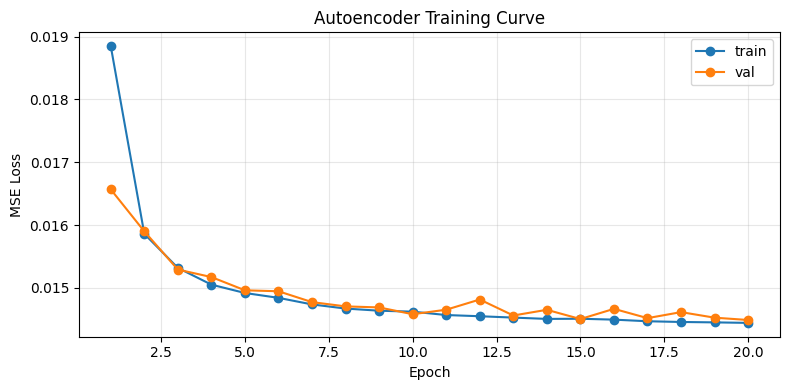

,epoch,train_loss,val_loss
15,16,0.014494,0.014666
16,17,0.014468,0.014518
17,18,0.014457,0.014614
18,19,0.014450,0.014525
19,20,0.014442,0.014488


In [15]:
history_path = REPO_ROOT / config["run"]["output_dir"] / "history.json"

if "history" in globals() and history:
    history_df = pd.DataFrame(history)
else:
    with history_path.open("r", encoding="utf-8") as f:
        history_df = pd.DataFrame(json.load(f))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
ax.set_title("Autoencoder Training Curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

history_df.tail()


In [16]:
output_dir = REPO_ROOT / config["run"]["output_dir"]
output_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "epoch": len(history),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": config,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "stale_epochs": stale_epochs,
        "history": history,
    },
    output_dir / "last_model.pt",
)

if best_state_dict is not None:
    torch.save(
        {
            "epoch": best_epoch,
            "model_state_dict": best_state_dict,
            "optimizer_state_dict": optimizer.state_dict(),
            "config": config,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "stale_epochs": stale_epochs,
            "history": history,
        },
        output_dir / "best_model.pt",
    )

with (output_dir / "history.json").open("w", encoding="utf-8") as handle:
    json.dump(history, handle, indent=2)

summary = {
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "epochs_ran": len(history),
    "resumed_from": resume_from,
}
with (output_dir / "summary.json").open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

print(f"Saved outputs to {output_dir}")
summary

Saved outputs to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\autoencoder_residual


{'best_epoch': 15,
 'best_val_loss': 0.014503520327806474,
 'epochs_ran': 20,
 'resumed_from': ''}

In [17]:
best_model_path = output_dir / "best_model.pt"
if best_model_path.exists():
    best_checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    print(f"Loaded best_model.pt from epoch {best_checkpoint.get('best_epoch', 'unknown')}")
else:
    print("best_model.pt not found. Using current in-memory model state.")

model.eval()

def reconstruction_error(inputs: torch.Tensor, outputs: torch.Tensor, score_name: str = ANOMALY_SCORE_NAME) -> torch.Tensor:
    if score_name == "mse_mean":
        return spatial_mean(squared_error_map(inputs, outputs))
    if score_name == "topk_abs_mean":
        return topk_spatial_mean(absolute_error_map(inputs, outputs), topk_ratio=TOPK_RATIO)
    raise ValueError(f"Unsupported score_name: {score_name}")

test_rows = metadata[metadata["split"] == "test"].reset_index(drop=True)
test_scores = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        scores = reconstruction_error(inputs, outputs, score_name=ANOMALY_SCORE_NAME).cpu().numpy()
        labels = labels.cpu().numpy()
        for score, label in zip(scores, labels):
            test_scores.append({"score": float(score), "is_anomaly": int(label)})

score_df = pd.DataFrame(test_scores)
print({"evaluation_score": ANOMALY_SCORE_NAME, "topk_ratio": TOPK_RATIO if ANOMALY_SCORE_NAME == "topk_abs_mean" else None})
score_df.head()

Loaded best_model.pt from epoch 15
{'evaluation_score': 'topk_abs_mean', 'topk_ratio': 0.01}


,score,is_anomaly
0,0.480986,0
1,0.578480,0
2,0.473288,0
3,0.609188,0
4,0.470258,0


In [18]:
val_scores = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        scores = reconstruction_error(inputs, outputs, score_name=ANOMALY_SCORE_NAME).cpu().numpy()
        val_scores.extend(scores.tolist())

val_score_series = pd.Series(val_scores, name="val_score")
threshold = float(val_score_series.quantile(0.95))
print(f"Chosen threshold from validation normals (95th percentile, {ANOMALY_SCORE_NAME}): {threshold:.6f}")
val_score_series.describe()

Chosen threshold from validation normals (95th percentile, topk_abs_mean): 0.537005


count    5000.000000
mean        0.482809
std         0.029608
min         0.294187
25%         0.469927
50%         0.479374
75%         0.487007
max         0.904225
Name: val_score, dtype: float64

In [19]:
score_df["predicted_anomaly"] = (score_df["score"] > threshold).astype(int)

precision = precision_score(score_df["is_anomaly"], score_df["predicted_anomaly"], zero_division=0)
recall = recall_score(score_df["is_anomaly"], score_df["predicted_anomaly"], zero_division=0)
f1 = f1_score(score_df["is_anomaly"], score_df["predicted_anomaly"], zero_division=0)
auroc = roc_auc_score(score_df["is_anomaly"], score_df["score"])
auprc = average_precision_score(score_df["is_anomaly"], score_df["score"])
cm = confusion_matrix(score_df["is_anomaly"], score_df["predicted_anomaly"])

metrics_df = pd.DataFrame(
    [
        {"metric": "score_name", "value": ANOMALY_SCORE_NAME},
        {"metric": "precision", "value": precision},
        {"metric": "recall", "value": recall},
        {"metric": "f1", "value": f1},
        {"metric": "auroc", "value": auroc},
        {"metric": "auprc", "value": auprc},
        {"metric": "threshold", "value": threshold},
    ]
)

display(metrics_df)
display(pd.DataFrame(cm, index=["true_normal", "true_anomaly"], columns=["pred_normal", "pred_anomaly"]))

,metric,value
0,score_name,topk_abs_mean
1,precision,0.356974
2,recall,0.604
3,f1,0.448737
4,auroc,0.804607
5,auprc,0.626014
6,threshold,0.537005


,pred_normal,pred_anomaly
true_normal,4728,272
true_anomaly,99,151


,threshold,precision,recall,f1,predicted_anomalies
5081,0.637794,0.878981,0.552,0.678133,156
5089,0.653303,0.906040,0.540,0.676692,148
5083,0.641135,0.883871,0.548,0.676543,154
5080,0.637026,0.873418,0.552,0.676471,157
5097,0.680135,0.936170,0.528,0.675192,140
5094,0.670863,0.923611,0.532,0.675127,143
5091,0.664335,0.911565,0.536,0.675063,146
5088,0.652733,0.900000,0.540,0.675000,149
5085,0.643353,0.888889,0.544,0.674938,152
5082,0.640522,0.878205,0.548,0.674877,155


Best F1 threshold: 0.637794 | precision=0.8790, recall=0.5520, f1=0.6781


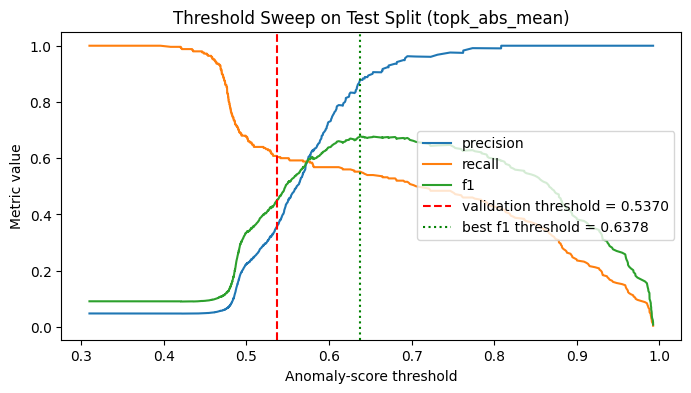

In [20]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    score_df["is_anomaly"],
    score_df["score"],
)

threshold_sweep_df = pd.DataFrame(
    {
        "threshold": pr_thresholds,
        "precision": precision_curve[:-1],
        "recall": recall_curve[:-1],
    }
)

threshold_sweep_df["f1"] = (
    2
    * threshold_sweep_df["precision"]
    * threshold_sweep_df["recall"]
    / (threshold_sweep_df["precision"] + threshold_sweep_df["recall"] + 1e-12)
)

threshold_sweep_df["predicted_anomalies"] = [
    int((score_df["score"] > t).sum()) for t in threshold_sweep_df["threshold"]
]

best_f1_row = threshold_sweep_df.loc[threshold_sweep_df["f1"].idxmax()]

display(threshold_sweep_df.sort_values("f1", ascending=False).head(10))
print(
    f"Best F1 threshold: {best_f1_row['threshold']:.6f} | "
    f"precision={best_f1_row['precision']:.4f}, recall={best_f1_row['recall']:.4f}, f1={best_f1_row['f1']:.4f}"
)

plt.figure(figsize=(8, 4))
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"], label="precision")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"], label="recall")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["f1"], label="f1")
plt.axvline(threshold, color="red", linestyle="--", label=f"validation threshold = {threshold:.4f}")
plt.axvline(best_f1_row["threshold"], color="green", linestyle=":", label=f"best f1 threshold = {best_f1_row['threshold']:.4f}")
plt.xlabel("Anomaly-score threshold")
plt.ylabel("Metric value")
plt.title(f"Threshold Sweep on Test Split ({ANOMALY_SCORE_NAME})")
plt.legend()
plt.show()


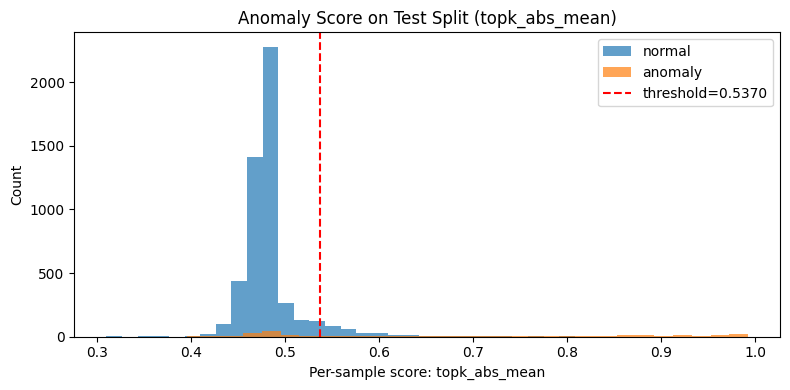

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(score_df[score_df["is_anomaly"] == 0]["score"], bins=30, alpha=0.7, label="normal")
ax.hist(score_df[score_df["is_anomaly"] == 1]["score"], bins=30, alpha=0.7, label="anomaly")
ax.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
ax.set_title(f"Anomaly Score on Test Split ({ANOMALY_SCORE_NAME})")
ax.set_xlabel(f"Per-sample score: {ANOMALY_SCORE_NAME}")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()

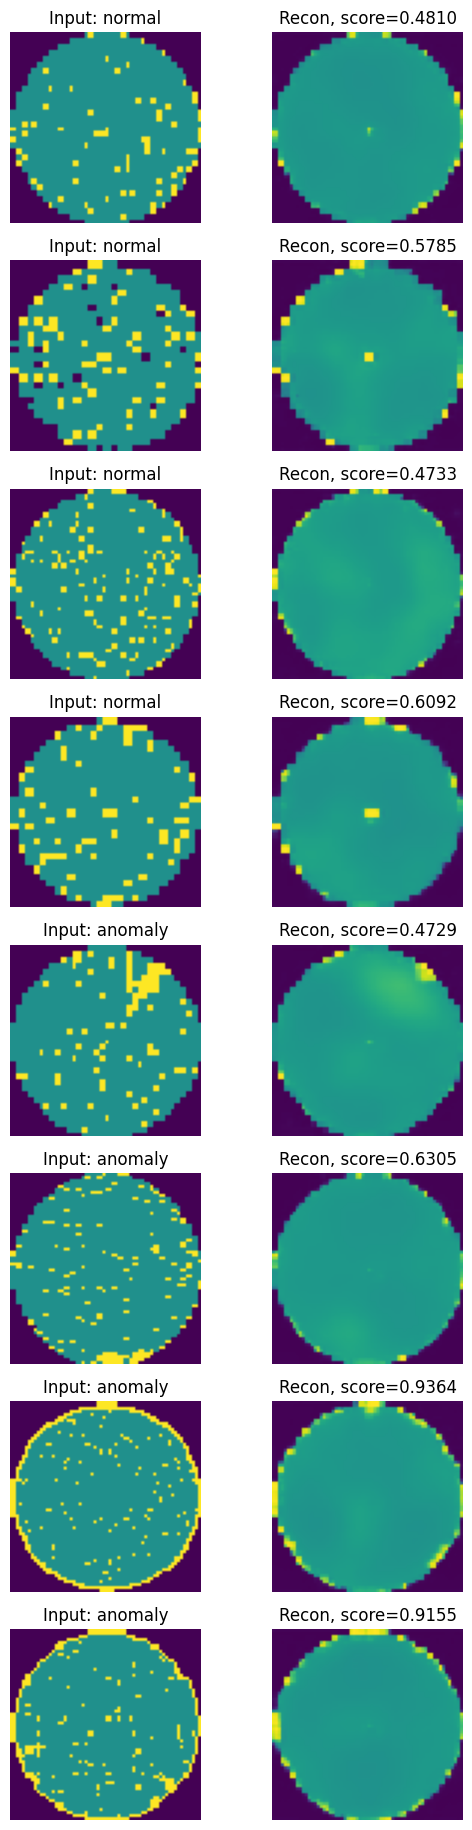

In [22]:
normal_test_idx = score_df[score_df["is_anomaly"] == 0].index[:4].tolist()
anomaly_test_idx = score_df[score_df["is_anomaly"] == 1].index[:4].tolist()
selected_indices = normal_test_idx + anomaly_test_idx

fig, axes = plt.subplots(len(selected_indices), 2, figsize=(6, 2.3 * len(selected_indices)))

with torch.no_grad():
    for row_idx, sample_idx in enumerate(selected_indices):
        input_tensor, label = test_dataset[sample_idx]
        output_tensor = model(input_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
        title_prefix = "anomaly" if int(label) == 1 else "normal"
        score = score_df.iloc[sample_idx]["score"]

        axes[row_idx, 0].imshow(input_tensor.squeeze(0), cmap="viridis")
        axes[row_idx, 0].set_title(f"Input: {title_prefix}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(output_tensor.squeeze(0), cmap="viridis")
        axes[row_idx, 1].set_title(f"Recon, score={score:.4f}")
        axes[row_idx, 1].axis("off")

plt.tight_layout()

## Failure Analysis

This section inspects the current autoencoder run using the selected main score.

Purpose:
- identify representative false positives, false negatives, true positives, and true negatives
- attach `defect_type` metadata when available
- decide whether the next change should target scoring, capacity, or model class


In [23]:
analysis_df = test_dataset.metadata.reset_index(drop=True).copy()
analysis_df = pd.concat(
    [analysis_df, score_df[["score", "predicted_anomaly"]].reset_index(drop=True)],
    axis=1,
)

analysis_df["error_type"] = "tn"
analysis_df.loc[(analysis_df["is_anomaly"] == 0) & (analysis_df["predicted_anomaly"] == 1), "error_type"] = "fp"
analysis_df.loc[(analysis_df["is_anomaly"] == 1) & (analysis_df["predicted_anomaly"] == 0), "error_type"] = "fn"
analysis_df.loc[(analysis_df["is_anomaly"] == 1) & (analysis_df["predicted_anomaly"] == 1), "error_type"] = "tp"
analysis_df["correct"] = analysis_df["is_anomaly"] == analysis_df["predicted_anomaly"]

error_summary_df = (
    analysis_df.groupby("error_type")
    .agg(count=("error_type", "size"), mean_score=("score", "mean"))
    .reindex(["tp", "fn", "fp", "tn"])
)

defect_recall_df = (
    analysis_df[analysis_df["is_anomaly"] == 1]
    .groupby("defect_type")
    .agg(
        count=("defect_type", "size"),
        detected=("predicted_anomaly", "sum"),
        mean_score=("score", "mean"),
    )
    .sort_values(["detected", "count"], ascending=[False, False])
)
defect_recall_df["recall"] = defect_recall_df["detected"] / defect_recall_df["count"]

fp_defect_df = (
    analysis_df[analysis_df["error_type"] == "fp"]
    .groupby("defect_type")
    .agg(count=("defect_type", "size"), mean_score=("score", "mean"))
    .sort_values(["count", "mean_score"], ascending=[False, False])
)

display(error_summary_df)
display(defect_recall_df)
display(fp_defect_df)

analysis_df.head()


,count,mean_score
error_type,,
tp,151,0.847068
fn,99,0.480705
fp,272,0.576203
tn,4728,0.477503


,count,detected,mean_score,recall
defect_type,,,,
Edge-Ring,84,72,0.859063,0.857143
Center,50,36,0.718931,0.720000
Edge-Loc,53,23,0.619669,0.433962
Loc,34,8,0.520317,0.235294
Donut,7,4,0.580256,0.571429
Random,5,4,0.659113,0.800000
Scratch,15,2,0.527178,0.133333
Near-full,2,2,0.795533,1.000000


,count,mean_score
defect_type,,
none,272,0.576203


,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width,score,predicted_anomaly,error_type,correct
0,data/processed/x64/wm811k/arrays/wafer_0045000...,none,none,0,test,Training,33,37,0.480986,0,tn,True
1,data/processed/x64/wm811k/arrays/wafer_0045001...,none,none,0,test,Training,27,25,0.578480,1,fp,False
2,data/processed/x64/wm811k/arrays/wafer_0045002...,none,none,0,test,Test,41,42,0.473288,0,tn,True
3,data/processed/x64/wm811k/arrays/wafer_0045003...,none,none,0,test,Training,27,27,0.609188,1,fp,False
4,data/processed/x64/wm811k/arrays/wafer_0045004...,none,none,0,test,Test,30,34,0.470258,0,tn,True


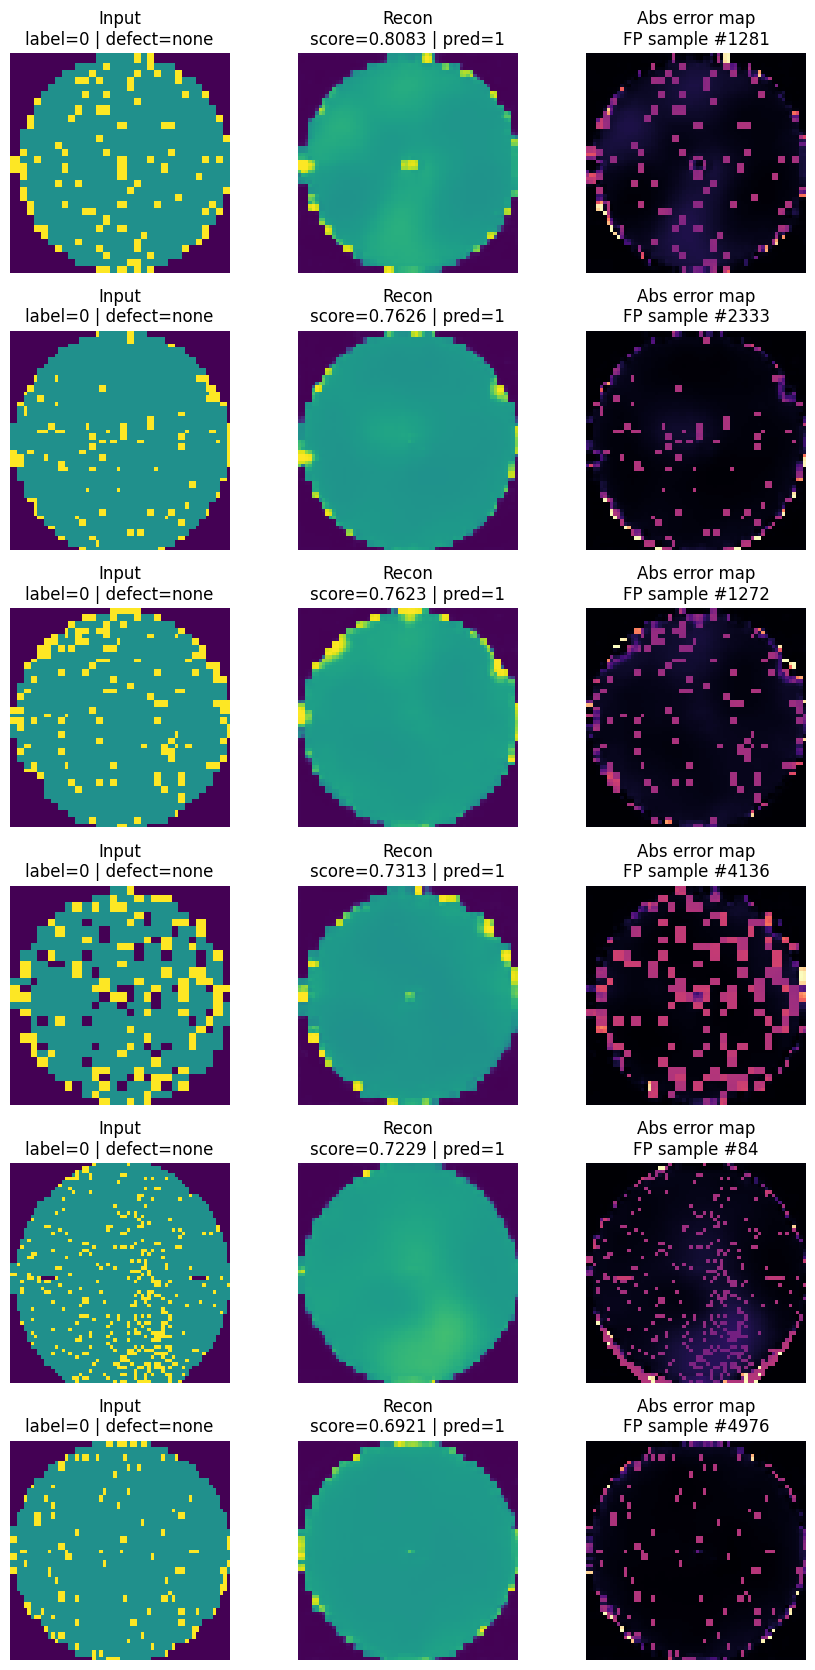

,defect_type,score,predicted_anomaly,error_type
1281,none,0.808299,1,fp
2333,none,0.762581,1,fp
1272,none,0.762293,1,fp
4136,none,0.731324,1,fp
84,none,0.722886,1,fp
4976,none,0.692094,1,fp


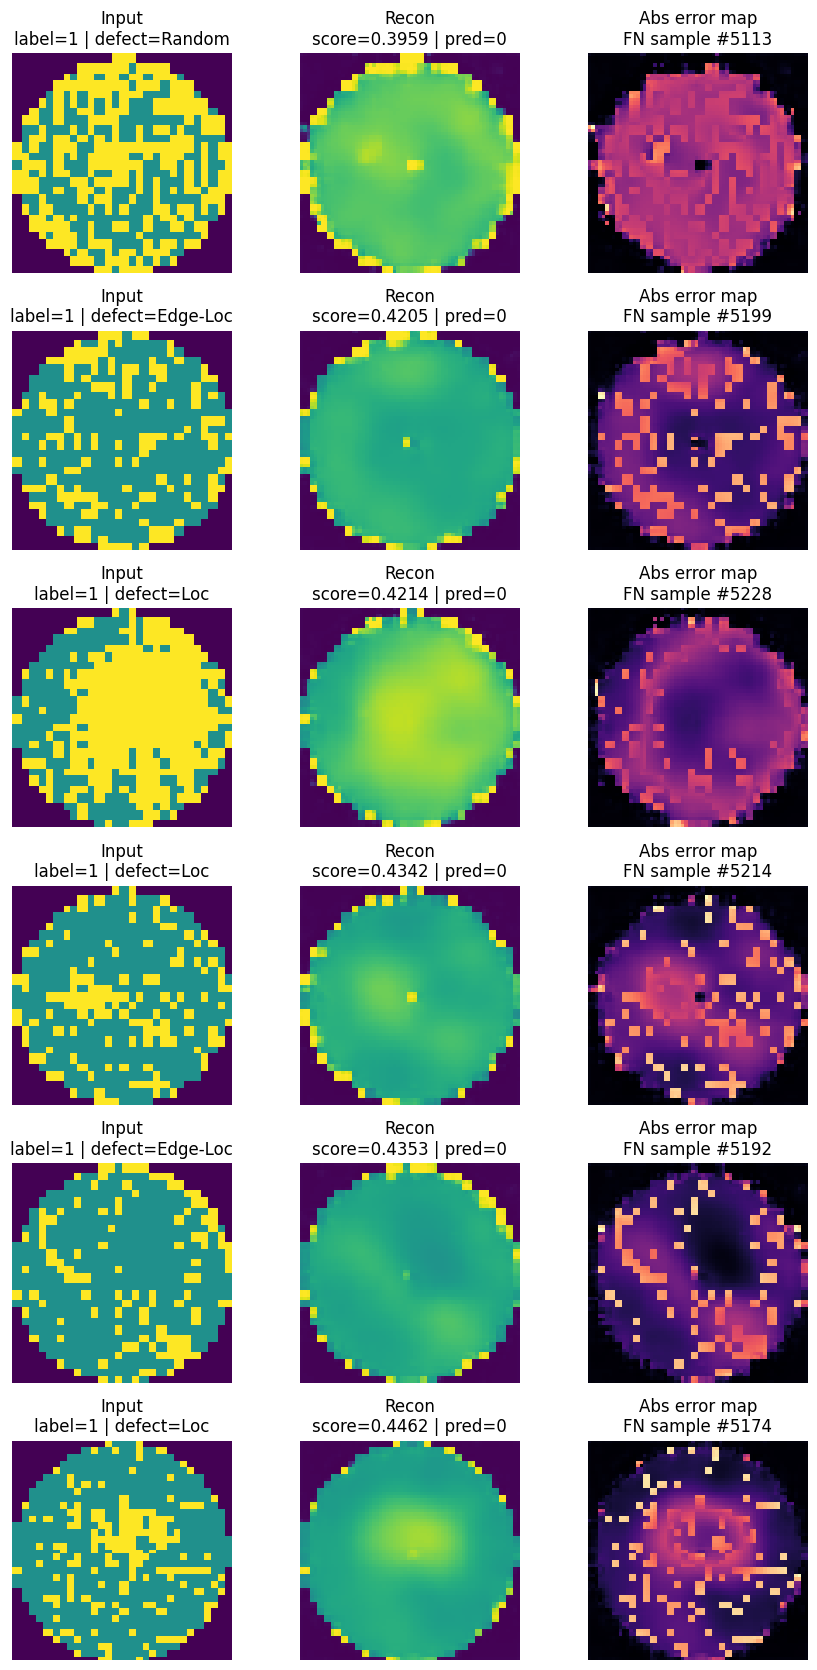

,defect_type,score,predicted_anomaly,error_type
5113,Random,0.395866,0,fn
5199,Edge-Loc,0.420542,0,fn
5228,Loc,0.421365,0,fn
5214,Loc,0.434205,0,fn
5192,Edge-Loc,0.435322,0,fn
5174,Loc,0.446232,0,fn


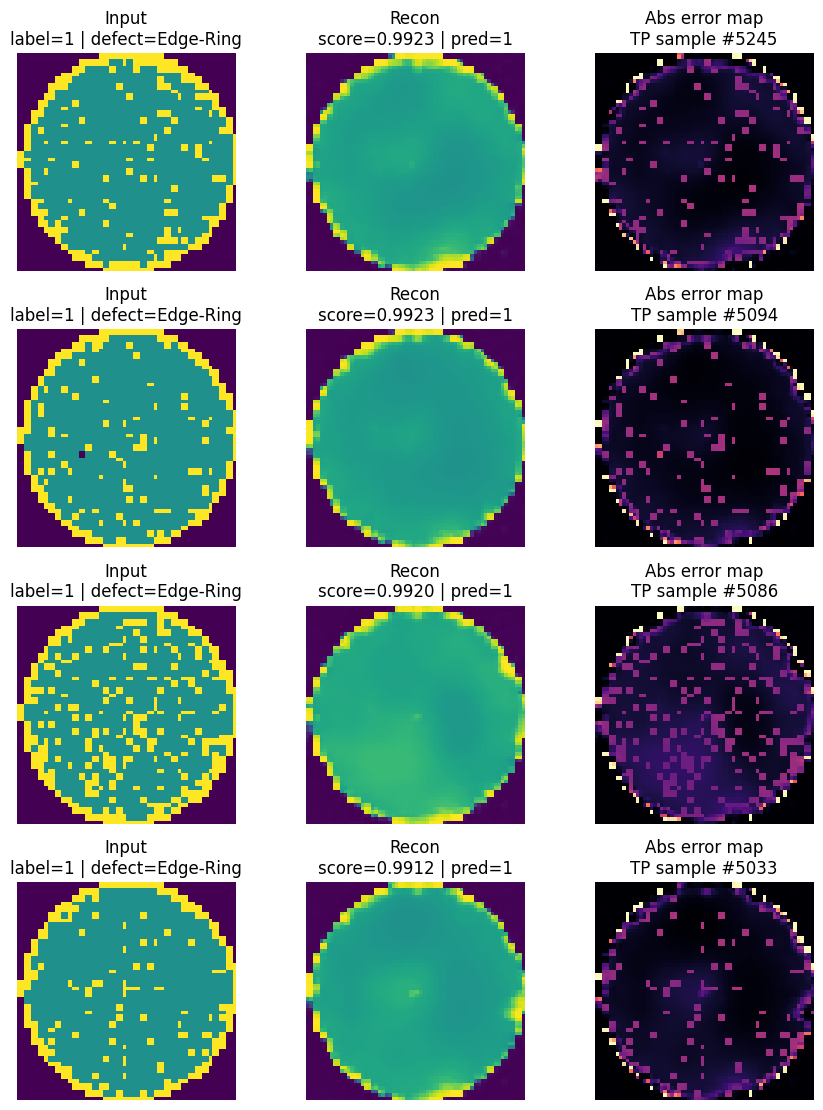

,defect_type,score,predicted_anomaly,error_type
5245,Edge-Ring,0.992350,1,tp
5094,Edge-Ring,0.992313,1,tp
5086,Edge-Ring,0.992020,1,tp
5033,Edge-Ring,0.991156,1,tp


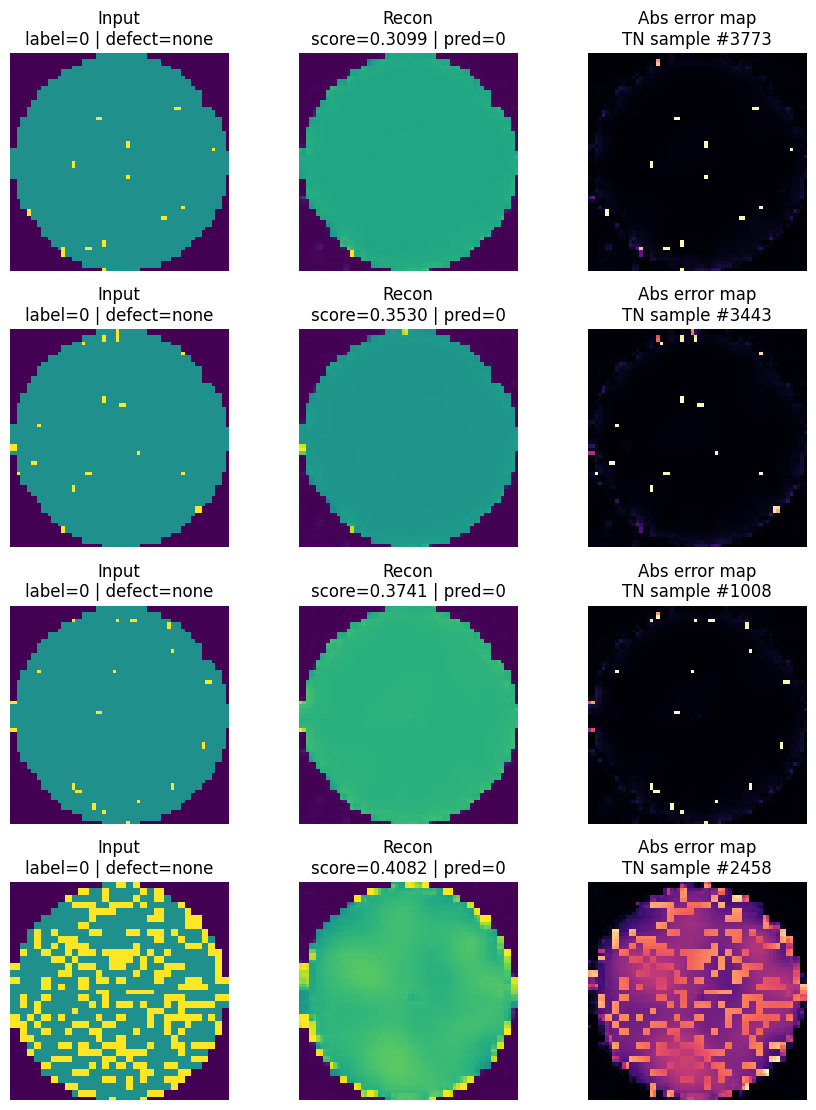

,defect_type,score,predicted_anomaly,error_type
3773,none,0.309949,0,tn
3443,none,0.353047,0,tn
1008,none,0.374110,0,tn
2458,none,0.408226,0,tn


In [24]:
def show_error_examples(error_type: str, n_examples: int = 6, score_order: str = "desc") -> pd.DataFrame:
    subset = analysis_df[analysis_df["error_type"] == error_type].copy()
    if subset.empty:
        print(f"No samples found for error_type={error_type!r}.")
        return subset

    ascending = score_order == "asc"
    subset = subset.sort_values("score", ascending=ascending).head(n_examples)
    fig, axes = plt.subplots(len(subset), 3, figsize=(9, 2.8 * len(subset)))
    if len(subset) == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row_idx, (sample_idx, row) in enumerate(subset.iterrows()):
            input_tensor, label = test_dataset[sample_idx]
            output_tensor = model(input_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
            error_map = absolute_error_map(input_tensor.unsqueeze(0), output_tensor.unsqueeze(0)).squeeze(0).squeeze(0).cpu()

            axes[row_idx, 0].imshow(input_tensor.squeeze(0), cmap="viridis")
            axes[row_idx, 0].set_title(
                f"Input\nlabel={int(label)} | defect={row.get('defect_type', 'unknown')}"
            )
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(output_tensor.squeeze(0), cmap="viridis")
            axes[row_idx, 1].set_title(
                f"Recon\nscore={row['score']:.4f} | pred={row['predicted_anomaly']}"
            )
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(error_map, cmap="magma")
            axes[row_idx, 2].set_title(f"Abs error map\n{error_type.upper()} sample #{sample_idx}")
            axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()
    return subset[["defect_type", "score", "predicted_anomaly", "error_type"]]


display(show_error_examples("fp", n_examples=6, score_order="desc"))
display(show_error_examples("fn", n_examples=6, score_order="asc"))
display(show_error_examples("tp", n_examples=4, score_order="desc"))
display(show_error_examples("tn", n_examples=4, score_order="asc"))


## Score Ablation

This section is separate from the main autoencoder experiment above.

Purpose:
- keep the current best `64x64` autoencoder checkpoint fixed
- compare multiple anomaly scoring rules without retraining
- identify whether scoring is the bottleneck before changing the model


In [25]:
import subprocess

score_ablation_config = config if "config" in globals() else load_toml(CONFIG_PATH)
score_ablation_output_root = REPO_ROOT / score_ablation_config["run"]["output_dir"]
score_ablation_best_model_path = score_ablation_output_root / "best_model.pt"
if not score_ablation_best_model_path.exists():
    raise FileNotFoundError(
        f"Best autoencoder checkpoint not found: {score_ablation_best_model_path}. "
        "You do not need to retrain if the checkpoint already exists, but the file must be present."
    )

score_ablation_output_dir = score_ablation_output_root / "score_ablation"
score_ablation_output_dir.mkdir(parents=True, exist_ok=True)

score_ablation_cmd = [
    sys.executable,
    "scripts/evaluate_autoencoder_scores.py",
    "--checkpoint",
    str(score_ablation_best_model_path.relative_to(REPO_ROOT)),
    "--config",
    str(CONFIG_PATH.relative_to(REPO_ROOT)),
    "--output-dir",
    str(score_ablation_output_dir.relative_to(REPO_ROOT)),
]

print("Running:")
print(" ".join(score_ablation_cmd))

subprocess.run(score_ablation_cmd, cwd=REPO_ROOT, check=True)

Running:
c:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\venv\Scripts\python.exe scripts/evaluate_autoencoder_scores.py --checkpoint artifacts\x64\autoencoder_residual\best_model.pt --config configs\training\train_autoencoder_residual.toml --output-dir artifacts\x64\autoencoder_residual\score_ablation


CompletedProcess(args=['c:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\venv\\Scripts\\python.exe', 'scripts/evaluate_autoencoder_scores.py', '--checkpoint', 'artifacts\\x64\\autoencoder_residual\\best_model.pt', '--config', 'configs\\training\\train_autoencoder_residual.toml', '--output-dir', 'artifacts\\x64\\autoencoder_residual\\score_ablation'], returncode=0)

In [26]:
score_ablation_df = pd.read_csv(score_ablation_output_dir / "score_summary.csv")
score_ablation_summary = json.loads((score_ablation_output_dir / "score_summary.json").read_text(encoding="utf-8"))

display(score_ablation_df)
score_ablation_summary

,score_name,threshold,val_threshold_precision,val_threshold_recall,val_threshold_f1,auroc,auprc,best_sweep_threshold,best_sweep_precision,best_sweep_recall,best_sweep_f1
0,max_abs,0.921727,0.374419,0.644,0.473529,0.843360,0.588907,0.989679,0.767442,0.528,0.625592
1,topk_abs_mean,0.537005,0.356974,0.604,0.448737,0.804607,0.626014,0.637794,0.878981,0.552,0.678133
2,mse_mean,0.025326,0.329700,0.484,0.392220,0.806132,0.426133,0.028999,0.593750,0.380,0.463415
3,foreground_mse,0.031990,0.270270,0.400,0.322581,0.778402,0.353748,0.036460,0.528302,0.336,0.410758
4,mae_mean,0.105502,0.232558,0.320,0.269360,0.734534,0.263283,0.119523,0.461538,0.240,0.315789
5,pooled_mae_mean,0.104191,0.222857,0.312,0.260000,0.728333,0.255770,0.115431,0.398734,0.252,0.308824
6,foreground_mae,0.133823,0.212209,0.292,0.245791,0.710838,0.230483,0.146732,0.333333,0.228,0.270784


{'checkpoint': 'artifacts\\x64\\autoencoder_residual\\best_model.pt',
 'topk_ratio': 0.01,
 'foreground_threshold': 0.0,
 'pool_kernel_size': 5,
 'threshold_quantile': 0.95,
 'scores': [{'score_name': 'max_abs',
   'threshold': 0.9217269420623779,
   'val_threshold_precision': 0.3744186046511628,
   'val_threshold_recall': 0.644,
   'val_threshold_f1': 0.47352941176470587,
   'auroc': 0.8433596000000001,
   'auprc': 0.5889067360947448,
   'best_sweep_threshold': 0.9896788001060486,
   'best_sweep_precision': 0.7674418604651163,
   'best_sweep_recall': 0.528,
   'best_sweep_f1': 0.6255924170611284},
  {'score_name': 'topk_abs_mean',
   'threshold': 0.5370050013065338,
   'val_threshold_precision': 0.35697399527186763,
   'val_threshold_recall': 0.604,
   'val_threshold_f1': 0.4487369985141159,
   'auroc': 0.8046068,
   'auprc': 0.6260135493468072,
   'best_sweep_threshold': 0.6377936601638794,
   'best_sweep_precision': 0.8789808917197452,
   'best_sweep_recall': 0.552,
   'best_sweep_f

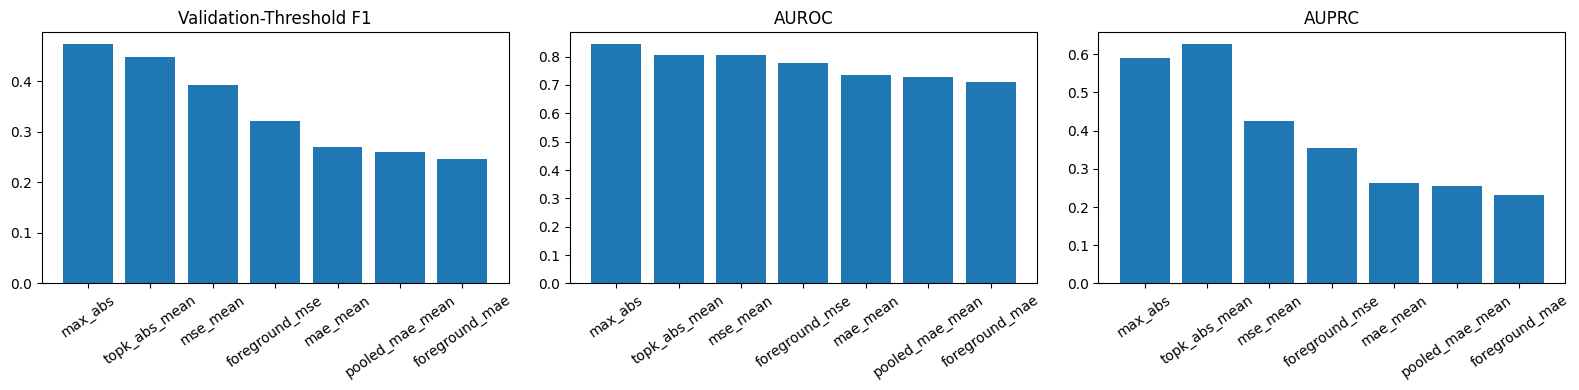

,score_name,val_threshold_f1,auroc,auprc,best_sweep_f1
0,max_abs,0.473529,0.843360,0.588907,0.625592
1,topk_abs_mean,0.448737,0.804607,0.626014,0.678133
2,mse_mean,0.392220,0.806132,0.426133,0.463415
3,foreground_mse,0.322581,0.778402,0.353748,0.410758
4,mae_mean,0.269360,0.734534,0.263283,0.315789
5,pooled_mae_mean,0.260000,0.728333,0.255770,0.308824
6,foreground_mae,0.245791,0.710838,0.230483,0.270784


In [27]:
top_scores = score_ablation_df.sort_values("val_threshold_f1", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(top_scores["score_name"], top_scores["val_threshold_f1"])
axes[0].set_title("Validation-Threshold F1")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(top_scores["score_name"], top_scores["auroc"])
axes[1].set_title("AUROC")
axes[1].tick_params(axis="x", rotation=35)

axes[2].bar(top_scores["score_name"], top_scores["auprc"])
axes[2].set_title("AUPRC")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

top_scores[["score_name", "val_threshold_f1", "auroc", "auprc", "best_sweep_f1"]]